In [1]:
import sys
import lib.dragon
sys.modules['dragon'] = sys.modules['lib.dragon']

In [2]:
import os
import sys
import importlib
import graphviz
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import openml

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dragon.search_space.bricks_variables import mlp_var, identity_var, operations_var, mlp_const_var, dag_var, node_var, activation_var
from dragon.search_space.base_variables import CatVar, Constant, DynamicBlock, IntVar, FloatVar, ArrayVar, Variable
from dragon.search_space.dag_encoding import AdjMatrix, Node
from dragon.search_space.dag_variables import NodeVariable, HpVar
from dragon.search_operators.base_neighborhoods import ArrayInterval, DynamicBlockInterval, CatInterval, ConstantInterval
from dragon.search_operators.dag_neighborhoods import CatHpInterval, NodeInterval
from dragon.utils.plot_functions import draw_cell, load_archi, str_operations

from dragon.utils.plot_functions import expr_to_mini_dag, graph_to_formula

import numpy as np
from dragon.utils.plot_functions import graph_to_formula


In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv(f"data/6000_points.csv")
df = df.drop(columns=['system:index', 'QA60', '.geo'])
df['NDVI'] = (df['B8']-df['B4'])/(df['B8']+df['B4'])

In [4]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,date,lat,lon,NDVI
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,2250,2023-03-23,37.335014,-95.326731,0.224758
1,1317,49,42,889,503,288,247,208,190,141,146,2023-06-04,-21.011541,-124.765524,-0.342657
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,1298,2023-01-26,11.062935,-11.792313,0.100790
3,1286,1291,444,980,823,532,832,1995,2736,2485,3134,2023-10-24,-1.910390,114.546423,0.647332
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,2015,2023-04-13,27.868199,120.743335,0.298813


### Test 0: with normalized data

In [5]:
X = pd.DataFrame({
    "B8": np.random.normal(0, 1, 1000),
    "B4": np.random.normal(0, 1, 1000)
})
z = pd.DataFrame({"NDVI": (X["B8"] - X["B4"]) / (X["B8"] + X["B4"])})

### Test 1: only the two relevant columns

In [6]:
X = df[['B8', 'B4', 'B8A']]
z = df[['NDVI']]

### Test 2: only the two relevant columns and one more

In [7]:
X = df[['B8', 'B4', 'B12']]
z = df[['NDVI']]

### Test 3: with all columns

In [8]:
X = df.drop(['NDVI', 'date'], axis=1)
z = df[['NDVI']]

### Feature Selection with XGBoost

Feature Importance Ranking:
   feature  importance
10     B8A    0.745472
5       B4    0.140400
9       B8    0.053102
1      B11    0.028917
3       B2    0.011175
4       B3    0.006344
0       B1    0.005789
8       B7    0.003857
6       B5    0.001582
2      B12    0.001349
7       B6    0.001101
11     lat    0.000705
12     lon    0.000207

Feature Scores Dictionary:
{'B8A': 0.7454718351364136, 'B4': 0.14040003716945648, 'B8': 0.05310237407684326, 'B11': 0.028917143121361732, 'B2': 0.011174793355166912, 'B3': 0.006344317924231291, 'B1': 0.0057885064743459225, 'B7': 0.0038567453157156706, 'B5': 0.0015818629181012511, 'B12': 0.0013491555582731962, 'B6': 0.0011011664755642414, 'lat': 0.0007050528656691313, 'lon': 0.00020709897216875106}


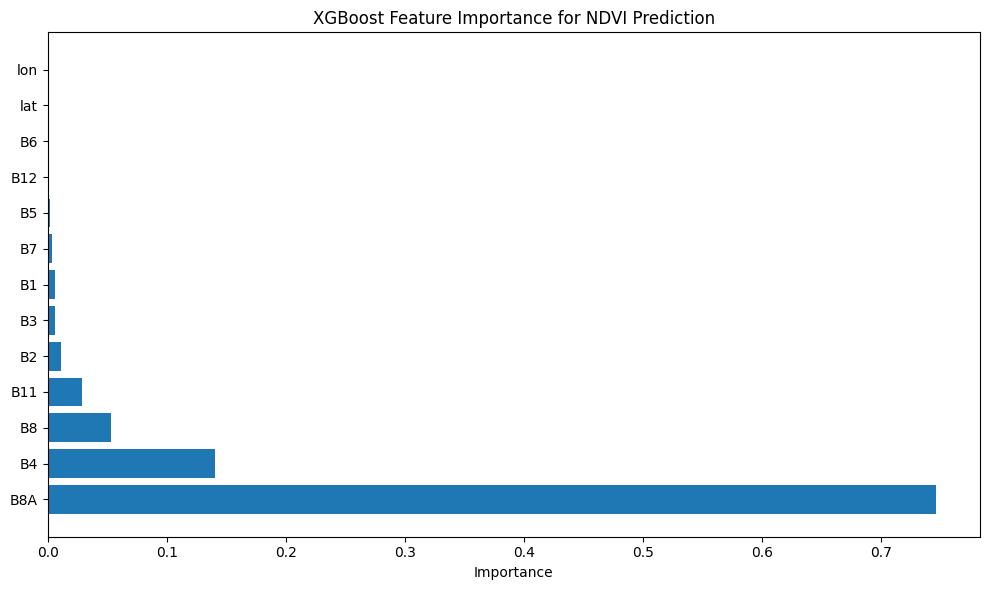


Top 10 features:
['B8A', 'B4', 'B8', 'B11', 'B2', 'B3', 'B1', 'B7', 'B5', 'B12']

Shape of original features: (2620, 13)
Shape of selected features: (2620, 10)


In [9]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalize features for XGBoost
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train XGBoost model for feature importance
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_scaled, z.values.ravel())

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
print(feature_importance)

# Create dictionary with performance scores for each feature
feature_scores_dict = dict(zip(feature_importance['feature'], feature_importance['importance']))
print("\nFeature Scores Dictionary:")
print(feature_scores_dict)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance for NDVI Prediction')
plt.tight_layout()
plt.show()

# Select top features (e.g., top 10)
top_n = 10
top_features = feature_importance.head(top_n)['feature'].tolist()
print(f"\nTop {top_n} features:")
print(top_features)

# Use selected features for your symbolic regression
X_selected = X[top_features]
print(f"\nShape of original features: {X.shape}")
print(f"Shape of selected features: {X_selected.shape}")

### Top x features selected

In [10]:
num_keep_features = 4
top_features = feature_importance.head(num_keep_features)['feature'].tolist()
X.drop(columns=[col for col in X.columns if col not in top_features], inplace=True)

In [11]:
X.head()

,B11,B4,B8,B8A
0,3202,1240,1959,2250
1,49,288,141,146
2,2031,968,1185,1298
3,1291,532,2485,3134
4,2050,975,1806,2015


In [12]:
X.shape

(2620, 4)

In [13]:
z.head()

,NDVI
0,0.224758
1,-0.342657
2,0.100790
3,0.647332
4,0.298813


In [14]:
class MetaArchi(nn.Module):
    def __init__(self, args, input_shape):
        super().__init__()
        self.input_shape = input_shape
        assert isinstance(args['Dag'], AdjMatrix), f"The 'Dag' argument should be an 'AdjMatrix'. Got {type(args['Dag'])} instead."
        self.dag = args['Dag']
        self.dag.set(input_shape)


    def forward(self, X):
        return self.dag(X)
    def set_prediction_to_save(self, name, df):
        if hasattr(self, "prediction"):
            self.prediction[name] = df
        else:
            self.prediction = {name: df}
    def save(self, path):
        if not os.path.exists(path):
            os.makedirs(path)
        full_path = os.path.join(path, "best_model.pth")
        torch.save(self.state_dict(), full_path)
        if hasattr(self, "prediction"):
            for k in self.prediction.keys():
                self.prediction[k].to_csv(os.path.join(path, f"best_model_{k}_outputs.csv"))

In [15]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_set = RegressionDataset(X, z)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

#### All possible combinations of feature indices for Select Features

In [16]:
from itertools import combinations

# Generate all possible combinations of feature indices
all_feature_combinations = []
num_features = 4 #13
for length in range(1, num_features):
    all_feature_combinations.extend([list(combo) for combo in combinations(range(num_features), length)])


In [17]:
all_feature_combinations

[[0],
 [1],
 [2],
 [3],
 [0, 1],
 [0, 2],
 [0, 3],
 [1, 2],
 [1, 3],
 [2, 3],
 [0, 1, 2],
 [0, 1, 3],
 [0, 2, 3],
 [1, 2, 3]]

In [20]:
from dragon.search_operators.base_neighborhoods import CatInterval, ConstantInterval
from dragon.search_operators.dag_neighborhoods import EvoDagInterval, HpInterval
from dragon.search_space.base_variables import CatVar, Constant
from dragon.search_space.bricks.basics import Identity
from dragon.search_space.bricks.symbolic_regression import *
from dragon.search_space.dag_variables import EvoDagVariable, HpVar
from dragon.search_space.bricks_variables import (
    operations_var,
    dag_var,
)
from dragon.search_space.base_variables import ArrayVar
from dragon.search_space.dag_encoding import SymbolicNode
from dragon.search_operators.base_neighborhoods import ArrayInterval

# ── Feature importance → CatVar weights ──────────────────────────────
# Build a per-feature probability vector aligned with X.columns,
# then convert it into per-combination weights for the CatVar.
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)
feature_probs = [feature_scores_dict.get(col, 1.0 / num_feat)
                 for col in feature_names_list]

combo_weights = SelectFeatures.combination_weights(
    feature_probs, all_feature_combinations
)

# ── Search-space variables ────────────────────────────────────────────
unary_var = HpVar(
    "UnaryOp",
    CatVar(
        "UnaryOpType",
        features=[Identity, Inverse, Negate],
        neighbor=CatInterval()
    ),
    hyperparameters={},
    neighbor=HpInterval()
)
select_features_var = HpVar(
    "SelectFeatures",
    Constant("SelectFeaturesOp", SelectFeatures, neighbor=ConstantInterval()),
    hyperparameters={
        "feature_indices": CatVar(
            "feature_indices",
            features=all_feature_combinations,
            weights=combo_weights,# biased by XGBoost importance
            neighbor=CatInterval()
        )
    },
    neighbor=HpInterval()
)


sum_var = HpVar(
    "Sum",
    Constant("SumOp", SumFeatures, neighbor=ConstantInterval()),
    hyperparameters={},
    neighbor=HpInterval()
)


candidate_operations = operations_var(
    "CandidateOperations",
    size=10,
    candidates=[
        select_features_var,
        unary_var,
        sum_var
    ],
    combiner_features=['add', 'mul'],
    activations=Constant(
        "id",
        value=nn.Identity(),
        neighbor=ConstantInterval()
    ),
    node_type=SymbolicNode
)

dag = EvoDagVariable(
                    label="Dag",
                    operations = candidate_operations,
                    init_complexity=2,
                    neighbor=EvoDagInterval(nb_mutations=1)
                )


search_space = ArrayVar(dag, label="Search Space", neighbor=ArrayInterval())

# LOSS

#### Optimization of constants

In [21]:
def loader_to_tensors(loader, device):
    Xs, ys = [], []
    for Xb, yb in loader:
        Xs.append(Xb)
        ys.append(yb)
    X = torch.cat(Xs, dim=0).to(device)
    y = torch.cat(ys, dim=0).to(device)
    return X, y

def fit_constants_lbfgs(model, X, y, steps=50, lr=1.0):
    model.train()
    const_params = [p for n, p in model.named_parameters() if n.endswith(".value") and p.requires_grad]
    print(const_params)
    if not const_params:
        return

    criterion = nn.MSELoss()
    opt = torch.optim.LBFGS(const_params, lr=lr, max_iter=steps, line_search_fn="strong_wolfe")

    def closure():
        opt.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        if torch.isnan(loss) or torch.isinf(loss):
            return loss
        loss.backward()
        return loss

    opt.step(closure)


#### Custom loss

#### Pearson correlation

In [22]:
def correl(pred, true):
    """Calculates the Pearson correlation coefficient"""
    # Convert to numpy if needed
    if isinstance(pred, torch.Tensor):
        pred = pred.numpy()
    if isinstance(true, torch.Tensor):
        true = true.numpy()
    
    # Calculate deviations from mean
    pred_dev = pred - pred.mean()
    true_dev = true - true.mean()
    
    # Calculate covariance
    cov = np.sum(pred_dev * true_dev)
    
    # Calculate standard deviations
    std_pred = np.sqrt(np.sum(pred_dev ** 2))
    std_true = np.sqrt(np.sum(true_dev ** 2))
    
    # Return correlation coefficient
    if std_pred == 0 or std_true == 0:
        return 0.0
    return cov / (std_pred * std_true + 1e-8)

LOSS 2

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get feature names and number of features dynamically
feature_names = X.columns.tolist()
num_features = X.shape[1]

def eval(args, eps=1e-1, num_features=num_features):
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    
    # # Optimization
    # rand = np.random.rand()
    # if rand > 0.5:
    #     X_train_full, y_train_full = loader_to_tensors(train_loader, device)
    #     fit_constants_lbfgs(model, X_train_full, y_train_full, steps=50, lr=1.0)

    model.eval()

    all_pred, all_true = [], []

    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0

    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 -(correl(pred_all[:, c:c+1], true_all))**2
            if loss < mse:
                mse = loss
                selected_c = c
        pred_all = pred_all[:, selected_c]

    pred_all = pred_all.squeeze().numpy()
    true_all = true_all.squeeze().numpy()

    close_matches = np.sum(np.abs(pred_all - true_all) < eps)
    fraction_close = close_matches / len(pred_all)
    var = np.abs(true_all.std() - pred_all.std())
    return model, pred_all, true_all, mse, fraction_close, var
    

def loss_function(args, idx, eps=1e-1, mse_threshold=0.04, feature_names=feature_names, *kwargs):
    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    model, y_pred, y_true, mse, fraction_close, var = eval(args, eps)

    try:
        expr = graph_to_formula(
            args['Dag'].matrix,
            np.asarray(feature_names),
            args['Dag'].operations
        )
    except Exception as e:
        expr = None

    print(
        f"Idx={idx}, MSE = {mse:.10f}, var={var:.6f} "
        f"fraction_close = {fraction_close:.4f}, "
        f"formula={expr}"
    )
    rand = np.random.rand()
    if rand > 0.5:
        if expr is not None:
            try:
                mini_dag = expr_to_mini_dag(expr, feature_names)
                args['Dag'] = mini_dag
                model, y_pred, y_true, mse, fraction_close, var = eval(args, eps)
                expr = graph_to_formula(
                    args['Dag'].matrix,
                    np.asarray(feature_names),
                    args['Dag'].operations
                )
                print(f"Idx={idx}, mini dag MSE={mse:.6f}, var = {var:.6f}, formula = {expr}")
            except Exception as e:
                pass
        model.mini_x = [v for v in args.values()]
    df = pd.DataFrame({
        "pred": y_pred,
        "true": y_true
    })
    model.set_prediction_to_save("prediction", df)
    return mse.item(), model #(mse+var).item(), model


In [ ]:
from dragon.search_algorithm.mutant_ucb import Mutant_UCB

T_mut = 1000
K = int(0.5*T_mut)
save_dir="save/NDVI_formula/"
search_algorithm = Mutant_UCB(
    search_space=search_space,
    evaluation=loss_function,
    T=T_mut,
    K=K,
    N=1,
    E=1000,
    save_dir=save_dir,
    clean_all=True,
    verbose=True
)
search_algorithm.run()
print("=================== First phase done. Starting second phase with more evaluations ===================")
T_mut=1000
search_algorithm = Mutant_UCB(
    search_space=search_space,
    evaluation=loss_function,
    T=T_mut,
    K=K,
    N=1,
    E=0.01,
    save_dir=save_dir,
    clean_all=False,
    verbose=True,
    pop_path=save_dir
)
search_algorithm.run()
# T_mut+=500
# search_algorithm = Mutant_UCB(
#     search_space=search_space,
#     evaluation=loss_function,
#     T=T_mut,
#     K=K,
#     N=1,
#     E=500,
#     save_dir=save_dir,
#     clean_all=False,
#     verbose=True,
#     pop_path=save_dir
# )
# search_algorithm.run()

2026-02-16 16:26:36,949 | WARNING | Install mpi4py if you want to use the distributed version.
2026-02-16 16:26:36,951 | INFO | save/NDVI_formula/ already exists. Deleting it.
2026-02-16 16:26:37,384 | INFO | The whole population has been created (size = 500), 500 have been randomy initialized.
Idx=0, MSE = 0.8899215460, var=1602.504272 fraction_close = 0.0000, formula=-B11
2026-02-16 16:26:37,402 | INFO | Best found! 0.8899215459823608 < inf
Idx=1, MSE = 0.8899216056, var=1602.504272 fraction_close = 0.0000, formula=B11
Idx=1, mini dag MSE=0.889922, var = 1602.504272, formula = B11
Idx=2, MSE = 0.8899215460, var=1602.504272 fraction_close = 0.0000, formula=-B11
Idx=2, mini dag MSE=0.889922, var = 1602.504272, formula = -B11
Idx=3, MSE = 0.9481206536, var=7193.255859 fraction_close = 0.0000, formula=B11 + B4 + B8 + B8A + 1/B8A + 1/B8 + 1/B4 + 1/B11
Idx=4, MSE = 0.8899216056, var=1602.504272 fraction_close = 0.0000, formula=-B11
Idx=4, mini dag MSE=0.889922, var = 1602.504272, formula =

# Post - Processing

In [27]:
from dragon.utils.plot_functions import graph_to_all_formulas

# Load the best model
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

# ─── Step 1: Run the model and find the best output channel ──────────────────
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)

model = MetaArchi(best_model_dict, input_shape=(num_feat,)).to(device)
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        all_pred.append(pred.detach().cpu())
        all_true.append(yb.detach().cpu())

pred_all = torch.cat(all_pred)
true_all = torch.cat(all_true)

# Select the best channel using the SAME criterion as the training eval:
#   minimise  1 - correl(...)²   ⟹   maximise  |correl|
selected_c = 0
best_loss = np.inf
if len(pred_all.shape) > 1:
    for c in range(pred_all.shape[-1]):
        loss = 1 - (correl(pred_all[:, c:c+1], true_all))**2
        if loss < best_loss:
            best_loss = loss
            selected_c = c
    pred_all = pred_all[:, selected_c]

pred_all = pred_all.squeeze().numpy()
true_all = true_all.squeeze().numpy()
print(f"Selected output channel: {selected_c}  (loss = {best_loss:.8f})")

# ─── Step 2: Extract the formula for the SELECTED channel ────────────────────
try:
    all_formulas = graph_to_all_formulas(
        best_model_dict['Dag'].matrix,
        np.asarray(feature_names_list),
        best_model_dict['Dag'].operations
    )
    print(f"\nAll output-channel formulas ({len(all_formulas)} channels):")
    for i, f_expr in enumerate(all_formulas):
        marker = " <<< SELECTED" if i == selected_c else ""
        print(f"  [{i}]: {f_expr}{marker}")

    original_expr = all_formulas[selected_c]
    print(f"\nSelected formula: {original_expr}")
except Exception as e:
    original_expr = None
    all_formulas = []
    print(f"Error extracting formulas: {e}")

# ─── Step 3: Post-processing alignment ───────────────────────────────────────
# Alignment: true ≈ a1 * pred + a0
A = np.column_stack([pred_all, np.ones_like(pred_all)])
coeffs, _, _, _ = np.linalg.lstsq(A, true_all, rcond=None)
a1, a0 = coeffs
pred_aligned = a1 * pred_all + a0
mse_final = np.mean((pred_aligned - true_all)**2)
print(f"\nPost-processing alignment: a1={a1:.6f}, a0={a0:.6f}, MSE={mse_final:.6f}")

# ─── Step 4: Final formula ───────────────────────────────────────────────────
if original_expr is not None:
    final_formula = f"{a1:.6f} * ({original_expr}) + {a0:.6f}"
    print(f"\nFinal aligned formula: {final_formula}")

Selected output channel: 2  (loss = -0.00000024)

All output-channel formulas (4 channels):
  [0]: -B11**2/(B11**2 + 1)
  [1]: -B4**2/(B4*(B11 + B4) + 1)
  [2]: -B8**2/(B8*(B4 + B8) + 1) <<< SELECTED
  [3]: B8A**2*(-B11 - B4 - B8 - B8A)/(2*B8A**2 + 1)

Selected formula: -B8**2/(B8*(B4 + B8) + 1)

Post-processing alignment: a1=-1.999988, a0=-0.999992, MSE=0.000000

Final aligned formula: -1.999988 * (-B8**2/(B8*(B4 + B8) + 1)) + -0.999992


XGBOOST qui donne un score pour ensuite le feed à selectfeatures, librairie XGboost ou sklearn
random forrest regression (devient non linéaire)
selection n features
si on arrive à chaque fois à l'avoir avec K, T, E différents
srun -u 
regarder le nombre d'itérations que pysr prend (100 par défaut)

### Formulas simplification

In [46]:
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

In [47]:
best_model_dict

{'Dag': ModuleList(
   (0): 
   (input shape) (1,) -- (combiner) add -- (op) Identity() -- (activation) Identity() -- (output shape) (1,)
   (1): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[0]) -- (activation) Identity() -- (output shape) (1,)
   (2): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[1]) -- (activation) Identity() -- (output shape) (1,)
   (3): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[2]) -- (activation) Identity() -- (output shape) (1,)
   (4): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[3]) -- (activation) Identity() -- (output shape) (1,)
   (5): 
   (input shape) (1,) -- (combiner) add -- (op) Identity() -- (activation) Identity() -- (output shape) (1,)
   (6): 
   (input shape) (1,) -- (combiner) add -- (op) Inverse() -- (activation) Identity() -- (output shape) (1,)
   (7): 
   (input shape) (1,) -- (combiner) mul -- (op

In [40]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,date,lat,lon,NDVI
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,2250,2023-03-23,37.335014,-95.326731,0.224758
1,1317,49,42,889,503,288,247,208,190,141,146,2023-06-04,-21.011541,-124.765524,-0.342657
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,1298,2023-01-26,11.062935,-11.792313,0.100790
3,1286,1291,444,980,823,532,832,1995,2736,2485,3134,2023-10-24,-1.910390,114.546423,0.647332
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,2015,2023-04-13,27.868199,120.743335,0.298813


In [41]:
# calclul = 4.000008 * (-B4*(B4 + B8)/(2*(B4 + B8)**2 + 1)) + 1.000001
calclul = 4.000008*(-df['B4']*(df['B4']+df['B8'])/(2*(df['B4']+df['B8'])**2 +1)) +1

In [42]:
calclul

0       0.224756
1      -0.342656
2       0.100788
3       0.647331
4       0.298812
          ...   
2615    0.051688
2616   -0.328828
2617   -0.028353
2618    0.415745
2619   -0.094652
Length: 2620, dtype: float64

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def eval(args, eps=1e-1,):
    model = MetaArchi(args, input_shape=(2,)).to(device)
    

    # # Optimization
    # rand = np.random.rand()
    # if rand > 0.5:
    #     X_train_full, y_train_full = loader_to_tensors(train_loader, device)
    #     fit_constants_lbfgs(model, X_train_full, y_train_full, steps=50, lr=1.0)

    model.eval()

    all_pred, all_true = [], []

    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0

    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 -(correl(pred_all[:, c:c+1], true_all))**2
            if loss < mse:
                mse = loss
                selected_c = c
        pred_all = pred_all[:, selected_c]

    pred_all = pred_all.squeeze().numpy()
    true_all = true_all.squeeze().numpy()



    close_matches = np.sum(np.abs(pred_all - true_all) < eps)
    fraction_close = close_matches / len(pred_all)
    var = np.abs(true_all.std() - pred_all.std())
    return model, pred_all, true_all, mse, fraction_close, var
    

def loss_function(args, idx, eps=1e-1, mse_threshold=0.04, *kwargs):
    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    model, y_pred, y_true, mse, fraction_close, var = eval(args, eps)

    try:
        expr = graph_to_formula(
            args['Dag'].matrix,
            np.asarray(['B4', 'B8']),
            args['Dag'].operations
        )
    except Exception as e:
        expr = None

    print(
        f"Idx={idx}, MSE = {mse:.6f}, var={var:.6f} "
        f"fraction_close = {fraction_close:.4f}, "
        f"formula={expr}"
    )
    rand = np.random.rand()
    if rand > 0.5:
        if expr is not None:
            try:
                mini_dag = expr_to_mini_dag(expr, ["B4", "B8"])
                args['Dag'] = mini_dag
                model, y_pred, y_true, mse, fraction_close, var = eval(args, eps)
                expr = graph_to_formula(
                    args['Dag'].matrix,
                    np.asarray(['B4', 'B8']),
                    args['Dag'].operations
                )
                print(f"Idx={idx}, mini dag MSE={mse:.6f}, var = {var:.6f}, formula = {expr}")
            except Exception as e:
                pass
        model.mini_x = [v for v in args.values()]
    df = pd.DataFrame({
        "pred": y_pred,
        "true": y_true
    })
    model.set_prediction_to_save("prediction", df)
    return (mse+var).item(), model
